# 20 — Fantasy defensivo: porterías a cero, paradas y goles recibidos

Hasta el notebook 19 el puntaje fantasy del proyecto era **solo ofensivo**: aparición, goles, asistencias, tarjetas y
penales fallados. Eso bastaba para comparar delanteros entre sí, pero dejaba a porteros y defensas con la mitad de su
trabajo sin contar. En el Fantasy Premier League real, un portero titular de un equipo sólido puede sacar más de la
mitad de sus puntos de porterías a cero y paradas.

Con las tablas `keepers` y `playingtime` que se extrajeron en la Fase 19, ya se puede cerrar ese hueco. Este notebook:

1. mide cuánto le faltaba al puntaje según la posición;
2. resuelve el problema difícil —**ningún jugador de campo tiene porterías a cero en FBref**— con un estimador, y lo
   valida contra los porteros, que son los únicos de quienes sí se conoce la verdad;
3. arma el **fantasy completo** y comprueba si la mitad defensiva acerca el puntaje a medir al jugador;
4. pregunta de quién es realmente la portería a cero: ¿del jugador o de su equipo?;
5. repite la comparación de las siete ligas, ahora **por posición**.

**Qué NO incluye**: el bonus (BPS) de FPL, que se reparte por partido con datos que FBref no publica.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

LIGAS = ["Liga MX", "Premier League", "La Liga", "Serie A", "Bundesliga", "Ligue 1", "Eredivisie"]
COLOR = dict(zip(LIGAS, estilo.CATEGORICA))          # el mismo color por liga que en el notebook 19
POSICIONES = liga.POSICIONES                          # GK, DF, MF, FW
NOMBRE_POS = {"GK": "Porteros", "DF": "Defensas", "MF": "Mediocampistas", "FW": "Delanteros"}
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)

## 1. Los datos y el hueco que hay que tapar

`filas` es jugador-equipo-temporada (con `playingtime` y `keepers` unidos) y `jt` es jugador-temporada. A `jt` se le
añade primero el puntaje ofensivo (`puntos_fantasy`, el de los notebooks 17-19) y encima el defensivo
(`puntos_defensivos`, nuevo).

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_defensivos(fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas)))

# Solo se comparan temporadas con TODOS los datos defensivos de su posición y con un mínimo de minutos: antes de
# 2014-15 no hay goles recibidos en cancha y antes de 2016-17 no hay penales atajados.
titulares = jt[jt["def_completo"] & (jt["minutes"] >= 1500)]
print(f"{len(jt):,} jugador-temporada en total; {jt['def_completo'].sum():,} con datos defensivos completos; "
      f"{len(titulares):,} de ellos con 1,500+ minutos")
print(f"Primera temporada con cobertura completa en las 7 ligas: "
      f"{jt.groupby('temporada_inicio')['def_completo'].mean().ge(0.99).idxmax()}")

antes_despues = titulares.groupby("pos_principal")[["pts_total", "pts_defensivos", "pts_total_completo"]].mean()
antes_despues.loc[POSICIONES].round(1)

59,452 jugador-temporada en total; 44,315 con datos defensivos completos; 17,688 de ellos con 1,500+ minutos
Primera temporada con cobertura completa en las 7 ligas: 2016


,pts_total,pts_defensivos,pts_total_completo
pos_principal,,,
GK,58.6,42.2,100.8
DF,58.7,16.8,75.4
MF,75.9,6.9,82.7
FW,101.5,0.0,101.5


Ahí está el hueco, medido: con el puntaje viejo un **portero** titular promediaba 58.6 puntos por temporada y un
**defensa** 58.7, contra 101.5 de un delantero. No es que porteros y defensas valgan la mitad en un fantasy: es que la
mitad de su trabajo no se estaba contando. Al añadir lo defensivo, el portero pasa a 100.8 y el defensa a 75.4,
mientras el delantero se queda exactamente igual (no recibe ni un punto defensivo, por regla de FPL). Las cuatro
posiciones pasan de un rango de 58 a 102 puntos a uno de 75 a 102.

Eso no significa que ahora las cuatro posiciones sean "iguales": el delantero sigue arriba, como en el fantasy real.
Significa que ya se pueden comparar sin que la comparación esté decidida de antemano por lo que falta medir.

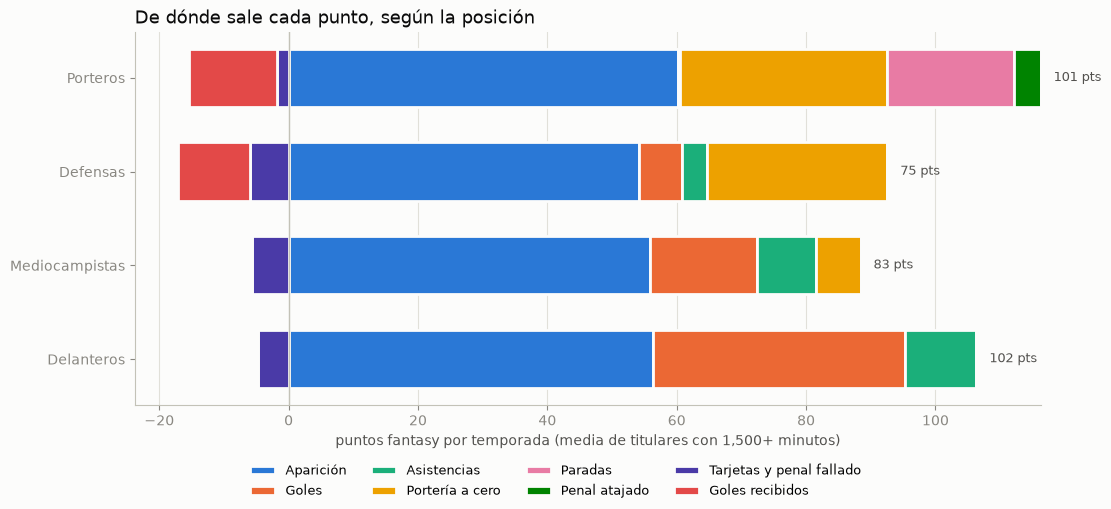

In [3]:
# El desglose completo: de dónde sale cada punto en cada posición. Son 8 conceptos porque ese es el tamaño de la
# paleta categórica validada: los dos castigos por indisciplina (tarjetas y penal fallado) van juntos en uno.
titulares = titulares.assign(pts_disciplina=titulares["pts_tarjetas"] + titulares["pts_penales"])
ETIQUETA = {"pts_aparicion": "Aparición", "pts_goles": "Goles", "pts_asistencias": "Asistencias",
            "pts_porteria_cero": "Portería a cero", "pts_paradas": "Paradas",
            "pts_penales_atajados": "Penal atajado", "pts_disciplina": "Tarjetas y penal fallado",
            "pts_goles_recibidos": "Goles recibidos"}
desglose = list(ETIQUETA)
medias = titulares.groupby("pos_principal")[desglose].mean().fillna(0).loc[POSICIONES]

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
y = np.arange(len(POSICIONES))
izquierda, derecha = np.zeros(len(POSICIONES)), np.zeros(len(POSICIONES))
for col, color in zip(desglose, estilo.CATEGORICA):
    v = medias[col].values
    # Los conceptos que restan (tarjetas, penal fallado, goles recibidos) se apilan a la IZQUIERDA del cero: apilar
    # negativos junto a positivos en la misma barra haría que la longitud total no significara nada.
    positivo, negativo = np.clip(v, 0, None), np.clip(v, None, 0)
    ax.barh(y, positivo, left=derecha, color=color, height=0.62, label=ETIQUETA[col],
            edgecolor=estilo.SUPERFICIE, linewidth=2)
    ax.barh(y, negativo, left=izquierda, color=color, height=0.62, edgecolor=estilo.SUPERFICIE, linewidth=2)
    derecha, izquierda = derecha + positivo, izquierda + negativo
for i, pos in enumerate(POSICIONES):
    ax.text(derecha[i] + 2, i, f"{medias.loc[pos].sum():.0f} pts", va="center", color=estilo.TINTA_2, fontsize=9)
ax.axvline(0, color=estilo.EJE, linewidth=1)
ax.set_yticks(y, [NOMBRE_POS[p] for p in POSICIONES])
ax.invert_yaxis()
ax.set_xlabel("puntos fantasy por temporada (media de titulares con 1,500+ minutos)")
ax.grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
fig.legend(*ax.get_legend_handles_labels(), loc="outside lower center", ncols=4, fontsize=9)
ax.set_title("De dónde sale cada punto, según la posición", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "fantasy_def_desglose.png", dpi=150)
plt.show()

El desglose explica por qué el cambio es tan desigual. En un **portero**, 42 de sus 101 puntos son defensivos: 32 de
porterías a cero, 20 de paradas y 4 de penales atajados, menos 14 de goles recibidos. En un **defensa** son 17 de 75,
y ahí la portería a cero es casi todo (28 puntos brutos, contra −11 de goles recibidos). El **mediocampista** apenas
nota el cambio (7 puntos, porque FPL solo le paga 1 por portería a cero y no le cobra los goles) y el **delantero**
nada.

Obsérvese también lo que pesa la simple aparición: entre 54 y 61 puntos en las cuatro posiciones. En un fantasy de
temporada completa, jugar es la mitad del negocio.

## 2. El problema difícil: porterías a cero de los jugadores de campo

FBref publica porterías a cero **solo de los porteros**. De un defensa sabemos cuántos goles recibió su equipo mientras
él estaba en la cancha (`on_goals_against`, desde 2014-15), pero no cómo se repartieron entre partidos, que es
justamente lo que decide una portería a cero: 10 goles pueden ser uno en cada uno de 10 partidos (cero porterías a
cero) o 10 en un solo partido (todas las demás a cero).

**La solución**: si los goles de un partido siguen una Poisson de media λ, la probabilidad de un partido sin goles es
e^(−λ). Enchufar λ̂ = goles/partidos en e^(−λ) sobreestima, porque la función es convexa; el estimador **insesgado** de
e^(−λ) para una Poisson es ((n−1)/n)^goles, con n = noventas jugados. Se multiplica por las titularidades porque FPL
solo paga la portería a cero a quien llegó a 60 minutos.

**La validación**: los porteros son el banco de pruebas perfecto, porque de ellos sí se conoce la verdad y se les puede
aplicar exactamente la misma fórmula. Si acierta con ellos, el supuesto de Poisson se sostiene.

               porteros   real  estimada  sesgo  error_absoluto  correlacion
1-5                1480  0.453     0.408 -0.044           0.249        0.778
6-15                810  2.114     2.123  0.010           0.780        0.783
16-25               615  4.938     4.775 -0.163           1.126        0.814
26+ (titular)      1637  9.181     9.066 -0.115           1.498        0.868
TODOS              4542  4.502     4.427 -0.076           0.913        0.956


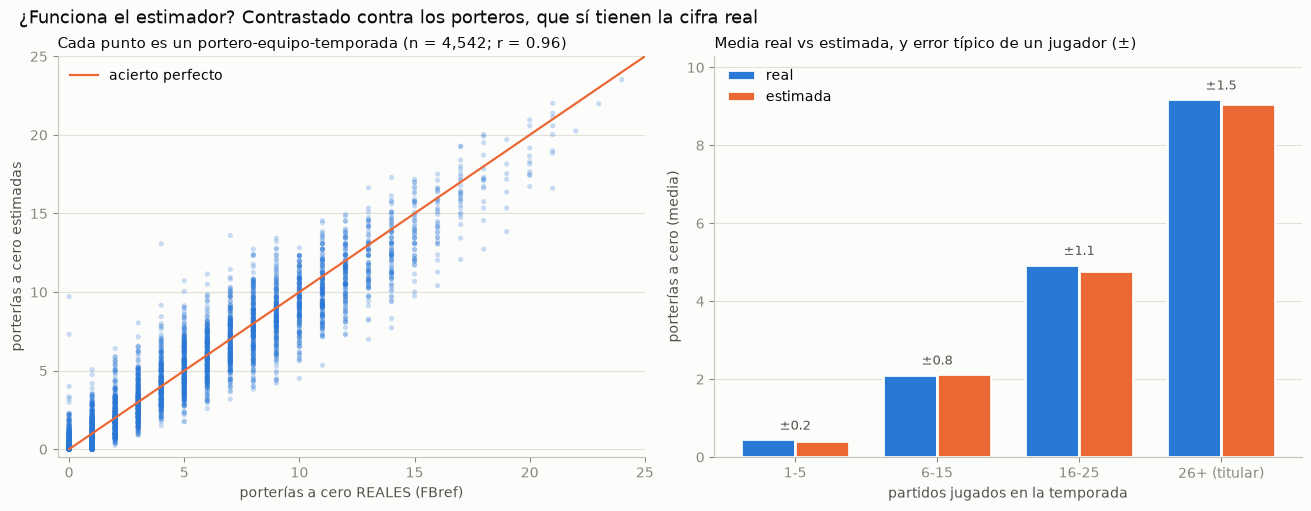

In [4]:
validacion = fantasy.validar_porterias_cero(filas)
print(validacion.round(3).to_string())

gk = filas[(filas["gk_games"].fillna(0) > 0) & filas["gk_clean_sheets"].notna() & filas["gk_goals_against"].notna()]
estimada = fantasy.porterias_cero_estimadas(gk["gk_games_starts"], gk["gk_minutes"] / 90, gk["gk_goals_against"])

fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
tope = 25
axs[0].scatter(gk["gk_clean_sheets"], estimada, s=14, color=estilo.AZUL, alpha=0.25, edgecolors="none")
axs[0].plot([0, tope], [0, tope], color=estilo.NARANJA, linewidth=1.6, label="acierto perfecto")
axs[0].set(xlim=(-0.5, tope), ylim=(-0.5, tope), xlabel="porterías a cero REALES (FBref)",
           ylabel="porterías a cero estimadas")
axs[0].set_title(f"Cada punto es un portero-equipo-temporada (n = {len(gk):,}; r = "
                 f"{estimada.corr(gk['gk_clean_sheets']):.2f})")
axs[0].legend(loc="upper left")
estilo.rejilla_y(axs[0])

tramos = validacion.drop(index="TODOS")
x = np.arange(len(tramos))
axs[1].bar(x - 0.19, tramos["real"], 0.38, color=estilo.AZUL, label="real", edgecolor=estilo.SUPERFICIE, linewidth=2)
axs[1].bar(x + 0.19, tramos["estimada"], 0.38, color=estilo.NARANJA, label="estimada",
           edgecolor=estilo.SUPERFICIE, linewidth=2)
for i, fila in enumerate(tramos.itertuples()):
    axs[1].text(i, max(fila.real, fila.estimada) + 0.25, f"±{fila.error_absoluto:.1f}", ha="center",
                color=estilo.TINTA_2, fontsize=9)
axs[1].set_xticks(x, tramos.index)
axs[1].set(xlabel="partidos jugados en la temporada", ylabel="porterías a cero (media)",
           ylim=(0, tramos[["real", "estimada"]].max().max() * 1.12))   # aire para las etiquetas del error
axs[1].set_title("Media real vs estimada, y error típico de un jugador (±)")
axs[1].legend()
estilo.rejilla_y(axs[1])
fig.suptitle("¿Funciona el estimador? Contrastado contra los porteros, que sí tienen la cifra real",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "fantasy_def_validacion.png", dpi=150)
plt.show()

El estimador funciona. Contra los 4,542 porteros-equipo-temporada de los que FBref sí publica la cifra real:
correlación **0.96**, sesgo de −0.08 porterías a cero por temporada (−1.7% del total) y error absoluto medio de 0.91.
El sesgo es prácticamente cero en todos los tramos, que es lo que importa para promedios de liga y de posición.

Lo que no hay que olvidar es la otra columna: en un portero titular el error típico es de **±1.5 porterías a cero**,
que a 4 puntos cada una son **±6 puntos fantasy**. Es decir, la estimación sirve para ordenar y para promediar, pero
el número de un jugador concreto no se puede leer como exacto. Los porteros conservan su cifra real; solo los
jugadores de campo llevan estimación.

In [5]:
# Caso concreto: un defensa que jugó TODOS los partidos tiene que recibir la cifra real de su equipo.
vd = jt[(jt["player"] == "Virgil van Dijk") & (jt["season"] == "2018-2019")].iloc[0]
liverpool = filas[(filas["team"] == "Liverpool") & (filas["season"] == "2018-2019") & filas["gk_games"].notna()]
print(f"Van Dijk 2018-19: {vd['games']:.0f} partidos, {vd['minutes']:,.0f} minutos, "
      f"{vd['on_goals_against']:.0f} goles recibidos con él en cancha")
print(f"  porterías a cero ESTIMADAS: {vd['porterias_cero']:.2f}")
print(f"  porterías a cero REALES del Liverpool (su portero): {liverpool['gk_clean_sheets'].sum():.0f}")

Van Dijk 2018-19: 38 partidos, 3,384 minutos, 22 goles recibidos con él en cancha
  porterías a cero ESTIMADAS: 21.00
  porterías a cero REALES del Liverpool (su portero): 21


El caso de Van Dijk muestra el mecanismo: jugó los 38 partidos de la Premier 2018-19 y el Liverpool recibió 22 goles
con él en cancha, así que el estimador le asigna 21.0 porterías a cero. Ese año el Liverpool dejó exactamente **21**
porterías a cero (las de Alisson, que jugó los mismos 38 partidos). Cuando un defensa juega todos los minutos, la
estimación tiene que reproducir la cifra real de su equipo, y lo hace.

### El otro detalle: FPL redondea DENTRO de cada partido

"+1 por cada 3 paradas" y "−1 por cada 2 goles recibidos" no se aplican al total de la temporada. Un portero con 3
paradas en un partido y 2 en el siguiente suma 1 + 0 = 1 punto, no 5/3. Con totales no sabemos el reparto por partido,
pero sí el promedio, y bajo la misma Poisson que ya se validó el valor esperado del redondeo se calcula exacto
(`fantasy.esperanza_piso`). No es un detalle menor:

In [6]:
gk_titular = gk[gk["gk_games"] >= 26]
partidos = gk_titular["gk_games"]
comparacion = pd.DataFrame({
    "dividiendo el total de la temporada": [
        (gk_titular["gk_saves"] / 3).mean(), -(gk_titular["gk_goals_against"] / 2).mean()],
    "con el redondeo por partido de FPL": [
        (fantasy.esperanza_piso(gk_titular["gk_saves"] / partidos, 3) * partidos).mean(),
        -(fantasy.esperanza_piso(gk_titular["gk_goals_against"] / partidos, 2) * partidos).mean()],
}, index=["Paradas (+1 por cada 3)", "Goles recibidos (−1 por cada 2)"])
comparacion["diferencia"] = comparacion.iloc[:, 1] - comparacion.iloc[:, 0]
print("Porteros con 26+ partidos, puntos por temporada:")
comparacion.round(1)

Porteros con 26+ partidos, puntos por temporada:


,dividiendo el total de la temporada,con el redondeo por partido de FPL,diferencia
Paradas (+1 por cada 3),33.6,22.5,-11.1
Goles recibidos (−1 por cada 2),-22.0,-14.5,7.6


La diferencia es grande: para un portero titular, repartir el total de la temporada daría +33.6 puntos por paradas,
cuando el redondeo por partido de FPL da +22.5; y −22.0 por goles recibidos donde corresponden −14.5. Son **19 puntos**
de diferencia por temporada, casi lo que separa a un defensa de un mediocampista. Un puntaje que dividiera los totales
estaría inflando sistemáticamente a los porteros de equipos malos, que son los que acumulan muchas paradas sueltas.

## 3. ¿La mitad defensiva acerca el puntaje a medir al jugador?

La prueba de siempre en este proyecto: si una métrica mide al jugador, quien sale alto un año tiende a salir alto al
siguiente. Se compara la estabilidad del puntaje **solo ofensivo** con la del **completo**, dentro de cada posición y
cada liga. Si añadir lo defensivo sube la estabilidad de porteros y defensas —y no toca a los delanteros, que no
reciben puntos defensivos— es que el puntaje nuevo captura algo real que antes se perdía.

In [7]:
comp_pos = liga.comparativa_posiciones(jt, LIGAS)
comp_pos.set_index(["league", "posicion"])[["temporadas", "pts_ofensivos", "pts_defensivos", "pts_completo",
                                            "pct_defensivo", "estab_ofensivo", "estab_completo", "pares"]].round(2)

temporadas  pts_ofensivos  pts_defensivos  pts_completo  pct_defensivo  estab_ofensivo  estab_completo  pares
league         posicion                                                                                                               
Liga MX        GK               163          53.25           41.22         94.46          43.63           -0.02            0.03     87
               DF               858          55.81           18.12         73.93          24.51            0.24            0.32    421
               MF               781          72.12            6.98         79.09           8.82            0.53            0.52    381
               FW               303          95.74            0.00         95.74           0.00            0.42            0.42    125
Premier League GK               211          61.74           43.43        105.18          41.29            0.36            0.43    119
               DF              1056          62.18           17.08         79.25          21.55            0.32            0.39    530
               MF              1136          80.43            7.07         87.50           8.08            0.60            0.59    536
               FW               430         106.36            0.00        106.36           0.00            0.58            0.58    178
La Liga        GK               226          59.88           45.66        105.53          43.26            0.15            0.35    119
               DF              1121          56.60           19.38         75.97          25.51            0.33            0.45    551
               MF              1052          73.90            7.45         81.35           9.15            0.50            0.49    489
               FW               452         103.73            0.00        103.73           0.00            0.66            0.66    196
Serie A        GK               205          61.03           43.86        104.90          41.81            0.34            0.35    123
               DF               973          58.40           18.94         77.34          24.49            0.43            0.47    472
               MF              1143          74.69            7.29         81.97           8.89            0.52            0.53    517
               FW               478         100.98            0.00        100.98           0.00            0.40            0.40    191
Bundesliga     GK               177          58.21           36.54         94.76          38.56            0.13            0.17    110
               DF               833          58.95           11.85         70.80          16.74            0.28            0.31    405
               MF               962          76.13            5.79         81.93           7.07            0.64            0.63    442
               FW               327         101.31            0.00        101.31           0.00            0.57            0.57    107
Ligue 1        GK               200          58.56           43.80        102.35          42.79            0.18            0.24    104
               DF              1009          57.93           18.72         76.65          24.43            0.26            0.29    420
               MF               998          73.93            6.94         80.87           8.58            0.55            0.52    402
               FW               395         101.44            0.00        101.44           0.00            0.55            0.55    134
Eredivisie     GK               154          55.75           38.52         94.26          40.86            0.24            0.37     50
               DF               892          60.72           11.86         72.58          16.34            0.28            0.42    356
               MF               752          79.67            6.15         85.82           7.17            0.54            0.54    271
               FW               401          99.19            0.00         99.19           0.00            0.3

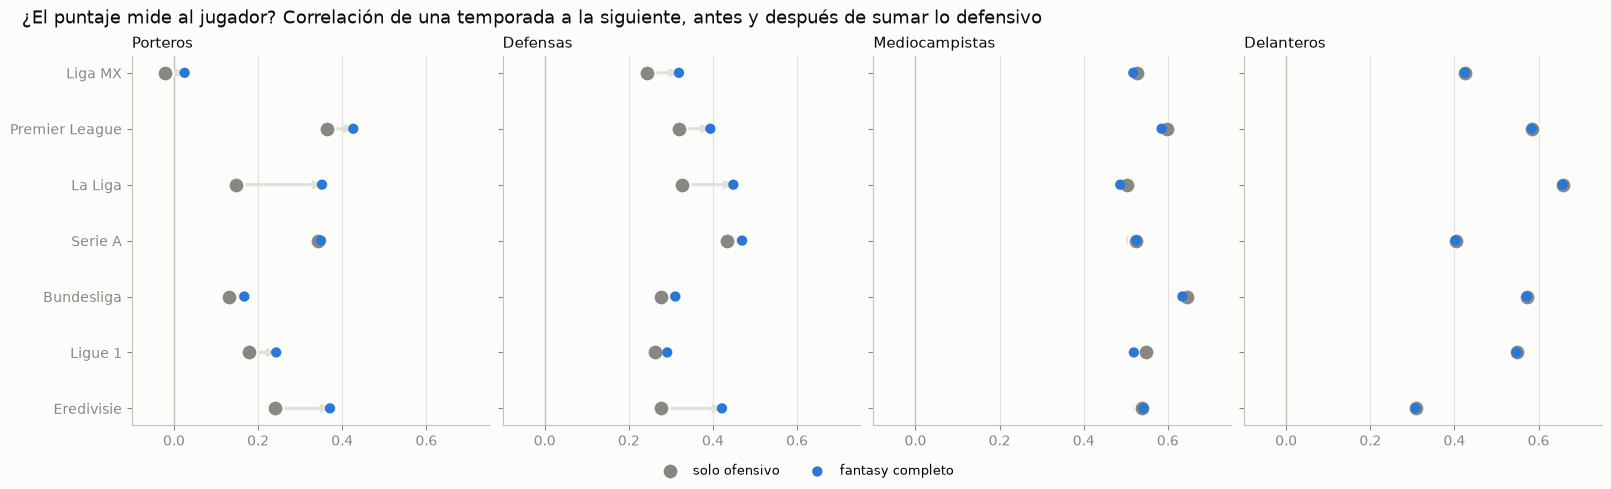

Cambio de estabilidad al añadir lo defensivo (media entre ligas y en cuántas de las 7 sube):
          media  ligas_donde_sube
posicion                         
GK        0.079                 7
DF        0.074                 7
MF       -0.010                 2
FW        0.000                 0


In [8]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.8), sharex=True, constrained_layout=True)
orden = LIGAS[::-1]                                   # de arriba a abajo en el orden de siempre
for ax, pos in zip(axs, POSICIONES):
    d = comp_pos[comp_pos["posicion"] == pos].set_index("league").reindex(orden)
    y = np.arange(len(orden))
    for i, (ofensivo, completo) in enumerate(zip(d["estab_ofensivo"], d["estab_completo"])):
        if np.isfinite(ofensivo) and np.isfinite(completo):
            ax.annotate("", xy=(completo, i), xytext=(ofensivo, i),
                        arrowprops=dict(arrowstyle="-|>", color=estilo.REJILLA, linewidth=2.2, shrinkA=0, shrinkB=0))
    # El gris se dibuja más grande y debajo: en los delanteros los dos valores son idénticos (no reciben puntos
    # defensivos) y así se sigue viendo el aro gris alrededor del azul en vez de un solo punto.
    ax.scatter(d["estab_ofensivo"], y, s=130, color=estilo.TENUE, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
               zorder=3, label="solo ofensivo")
    ax.scatter(d["estab_completo"], y, s=55, color=estilo.AZUL, edgecolors="none", zorder=4,
               label="fantasy completo")
    ax.axvline(0, color=estilo.EJE, linewidth=1)
    ax.set_yticks(y, orden if pos == POSICIONES[0] else [""] * len(orden))
    ax.set_title(NOMBRE_POS[pos])
    ax.set_xlim(-0.1, 0.75)
    ax.grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
fig.legend(*axs[0].get_legend_handles_labels(), loc="outside lower center", ncols=2, fontsize=9)
fig.suptitle("¿El puntaje mide al jugador? Correlación de una temporada a la siguiente, antes y después de sumar lo "
             "defensivo", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "fantasy_def_estabilidad.png", dpi=150)
plt.show()

subidas = comp_pos.assign(sube=comp_pos["estab_completo"] - comp_pos["estab_ofensivo"])
print("Cambio de estabilidad al añadir lo defensivo (media entre ligas y en cuántas de las 7 sube):")
print(subidas.groupby("posicion")["sube"].agg(media="mean", ligas_donde_sube=lambda s: int((s > 0).sum()))
      .loc[POSICIONES].round(3).to_string())

Este es el resultado que justifica todo el notebook. Al añadir la mitad defensiva, la estabilidad de un año al
siguiente **sube en las siete ligas** para porteros (+0.08 de media) y para defensas (+0.07), no cambia en
mediocampistas (−0.01, sube solo en 2 de 7) y es idéntica en delanteros, que no reciben puntos defensivos. El patrón
es exactamente el que se esperaría si lo defensivo estuviera midiendo algo real que antes se perdía, y no el que se
vería si solo estuviéramos añadiendo ruido.

Los casos extremos: en **La Liga** los porteros pasan de 0.15 a 0.35 y en la **Eredivisie** de 0.24 a 0.37; los
defensas de la Eredivisie, de 0.28 a 0.42. La excepción es la **Liga MX**, donde el puntaje de los porteros sigue sin
repetirse de un año al otro (−0.02 → 0.03): con Apertura y Clausura, plantillas que rotan más que en ninguna otra liga
del panel y porteros que cambian de equipo con frecuencia, una temporada de portero mexicano no dice casi nada de la
siguiente.

Aun así, conviene leer las cifras con la escala correcta: 0.3-0.45 sigue siendo mucho menos que el 0.5-0.66 de los
delanteros. Añadir lo defensivo mejora el puntaje de porteros y defensas, pero no lo convierte en una medida limpia
del jugador. La sección siguiente explica por qué.

## 4. ¿De quién es la portería a cero, del jugador o del equipo?

La estabilidad de arriba no distingue entre "este defensa es bueno" y "este defensa juega en un equipo bueno". Hay una
forma de separarlas: mirar qué pasa **cuando el jugador cambia de equipo**. Si dejar la portería a cero fuera una
cualidad suya, se la llevaría al mudarse y la correlación entre temporadas sería parecida en los dos casos. Si es sobre
todo del equipo, al cambiar de club se desploma.

posicion  r_mismo_equipo  n_mismo_equipo  r_cambio_equipo  n_cambio_equipo  caida
      GK           0.374             645            0.297              124  0.078
      DF           0.489            2791            0.276              624  0.213
      MF           0.469            2656            0.316              637  0.153
      FW           0.501             871            0.259              281  0.242


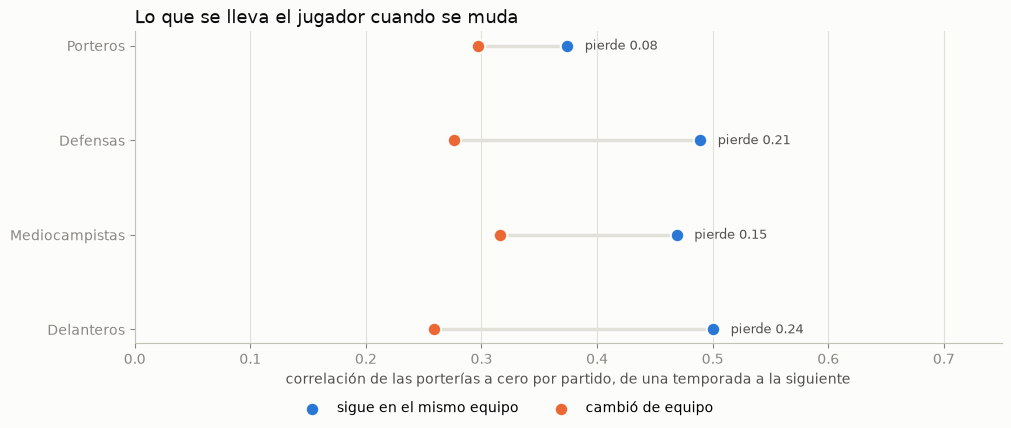

In [9]:
origen = liga.origen_porteria_cero(jt)
print(origen.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
y = np.arange(len(origen))
for i, fila in origen.iterrows():
    ax.plot([fila["r_cambio_equipo"], fila["r_mismo_equipo"]], [i, i], color=estilo.REJILLA, linewidth=2.5, zorder=1)
    ax.text(fila["r_mismo_equipo"] + 0.015, i, f"pierde {fila['caida']:.2f}", va="center", fontsize=9,
            color=estilo.TINTA_2)
ax.scatter(origen["r_mismo_equipo"], y, s=95, color=estilo.AZUL, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
           zorder=2, label="sigue en el mismo equipo")
ax.scatter(origen["r_cambio_equipo"], y, s=95, color=estilo.NARANJA, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
           zorder=2, label="cambió de equipo")
ax.set_yticks(y, [f"{NOMBRE_POS[p]}" for p in origen["posicion"]])
ax.invert_yaxis()
ax.set_xlim(0, 0.75)
ax.set_xlabel("correlación de las porterías a cero por partido, de una temporada a la siguiente")
ax.grid(axis="x", color=estilo.REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
fig.legend(*ax.get_legend_handles_labels(), loc="outside lower center", ncols=2)
ax.set_title("Lo que se lleva el jugador cuando se muda", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "fantasy_def_origen.png", dpi=150)
plt.show()

Aquí está la razón. Cuando un jugador **sigue en el mismo equipo**, sus porterías a cero por partido se repiten
bastante (r entre 0.37 y 0.50 según la posición). Cuando **cambia de equipo**, la correlación se desploma: un defensa
pierde 0.21 (de 0.49 a 0.28) y un delantero 0.24. O sea que más de la mitad de lo que parecía "este defensa deja la
portería a cero" era en realidad "este defensa juega en un equipo que deja la portería a cero".

La excepción es el **portero**: pierde solo 0.08 (de 0.37 a 0.30), la caída más pequeña de las cuatro posiciones. Es
el único que se lleva una parte apreciable de su portería a cero cuando se muda. Tiene sentido —es quien más
directamente interviene en que el balón no entre— y encaja con lo que ya se vio en el notebook 19, donde el % de
paradas era la métrica de portero más estable.

Dos advertencias: quien cambia de equipo suele cambiar también de nivel de rival y de rol, así que parte de la caída
no es "pérdida de señal" sino cambio de contexto; y la muestra de los que cambian es más pequeña (124 porteros contra
645 que se quedaron), así que el 0.30 de los porteros carga más incertidumbre que el resto de las cifras.

## 5. Las 7 ligas, ahora por posición

La comparativa del notebook 19 trataba a todos los jugadores juntos. Con el puntaje completo ya se puede preguntar
dónde vale más cada posición.

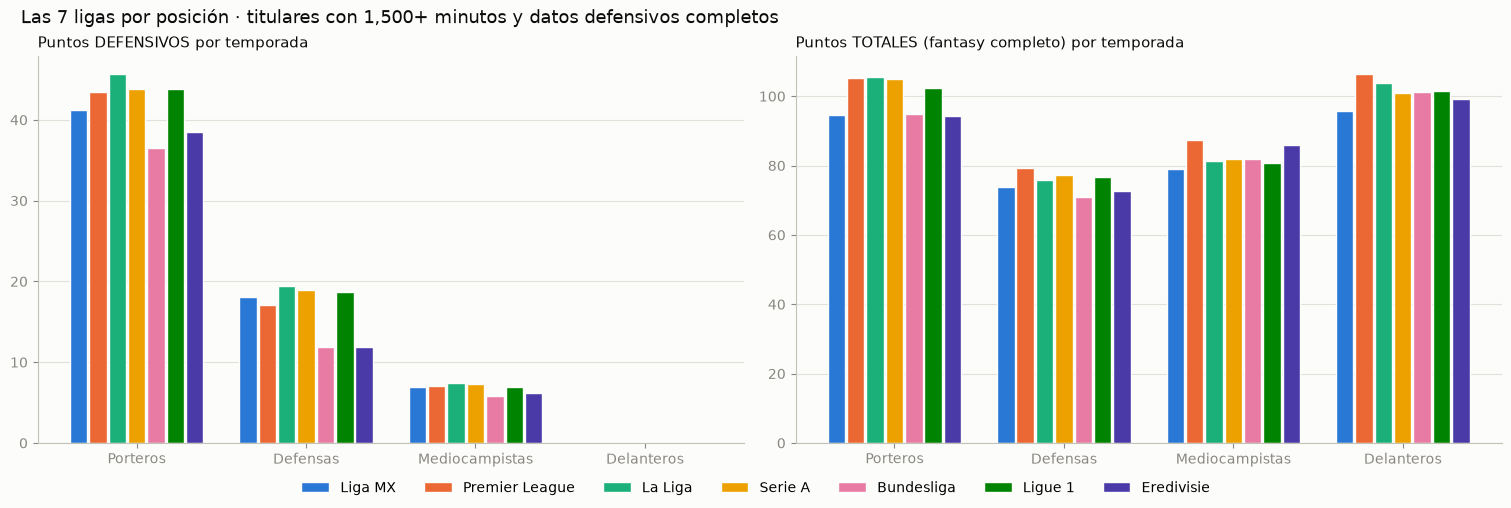

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for ax, (columna, titulo) in zip(axs, [("pts_defensivos", "Puntos DEFENSIVOS por temporada"),
                                       ("pts_completo", "Puntos TOTALES (fantasy completo) por temporada")]):
    ancho = 0.8 / len(LIGAS)
    x = np.arange(len(POSICIONES))
    for k, nombre in enumerate(LIGAS):
        d = comp_pos[comp_pos["league"] == nombre].set_index("posicion").reindex(POSICIONES)
        ax.bar(x + (k - (len(LIGAS) - 1) / 2) * ancho, d[columna], ancho * 0.9, color=COLOR[nombre], label=nombre,
               edgecolor=estilo.SUPERFICIE, linewidth=1)
    ax.set_xticks(x, [NOMBRE_POS[p] for p in POSICIONES])
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
fig.legend(*axs[0].get_legend_handles_labels(), loc="outside lower center", ncols=len(LIGAS))
fig.suptitle("Las 7 ligas por posición · titulares con 1,500+ minutos y datos defensivos completos",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / "fantasy_def_ligas_posicion.png", dpi=150)
plt.show()

Los puntos defensivos disponibles no son iguales en todas partes. Un portero de **La Liga** promedia 45.7 puntos
defensivos por temporada y uno de la **Bundesliga** 36.5: nueve puntos de diferencia que no dependen del portero sino
de cuántos goles se meten en su liga (la Bundesliga es la más goleada del panel, como se vio en el notebook 19). Entre
los defensas la brecha es proporcionalmente mayor: 19.4 en La Liga contra 11.9 en Bundesliga y Eredivisie, casi el
doble.

En el total, las ligas se ordenan parecido en las cuatro posiciones y las diferencias son moderadas (porteros de 94 a
106, defensas de 71 a 79). La lectura práctica: **un defensa de La Liga y uno de la Eredivisie no son comparables por
puntos brutos**, aunque jueguen el mismo número de minutos. Para compararlos hay que usar el percentil dentro de su
liga-temporada-posición (`pct_pts_completo` en el dataset), que es justamente para lo que existe esa columna.

In [11]:
print("Las mejores temporadas del fantasy COMPLETO, por posición:")
cols = ["player", "equipo_principal", "league", "season", "pts_total", "pts_defensivos", "pts_total_completo"]
for pos in POSICIONES:
    print(f"\n{NOMBRE_POS[pos]}:")
    print(titulares[titulares["pos_principal"] == pos].nlargest(5, "pts_total_completo")[cols]
          .round(1).to_string(index=False))

Las mejores temporadas del fantasy COMPLETO, por posición:

Porteros:
               player equipo_principal  league    season  pts_total  pts_defensivos  pts_total_completo
            Jan Oblak  Atlético Madrid La Liga 2017-2018       73.0           120.7               193.7
Marc-André ter Stegen        Barcelona La Liga 2022-2023       76.0           115.9               191.9
            Jan Oblak  Atlético Madrid La Liga 2015-2016       76.0           107.6               183.6
         Mike Maignan            Lille Ligue 1 2020-2021       75.0           100.2               175.2
            Jan Oblak  Atlético Madrid La Liga 2020-2021       76.0            97.1               173.1

Defensas:
                player equipo_principal         league    season  pts_total  pts_defensivos  pts_total_completo
      Yannick Carrasco           Monaco        Ligue 1 2014-2015      129.0            70.0               199.0
          Sergio Ramos      Real Madrid        La Liga 2019-2020      1

Los mejores por posición confirman que el puntaje ya reconoce a quien debe. Entre los **porteros**, tres temporadas de
Oblak en el Atlético y la de ter Stegen 2022-23 en el Barcelona, todas con más de 95 puntos defensivos; la de Oblak
2017-18 (193.7 puntos, 120.7 de ellos defensivos) corresponde al Atlético que recibió 22 goles en 38 partidos. Entre
los **defensas**, Van Dijk 2018-19 y Sergio Ramos 2019-20 conviven con laterales muy ofensivos como
Alexander-Arnold.

Un detalle que conviene mirar de frente: Carrasco encabeza la lista de defensas con su temporada 2014-15 en el Monaco,
y era un extremo. `pos_principal` es la **primera** posición que FBref le asigna, y a él le pone "DF,FW". No es un
error de cálculo sino un límite del dato: la posición del proyecto es la de FBref, y FBref la asigna por temporada
según dónde jugó. En las listas por posición conviene tenerlo presente.

## 6. Conclusiones

1. **El hueco estaba medido y ya está tapado.** Porteros y defensas promediaban 59 puntos contra 102 de los
   delanteros; con la mitad defensiva pasan a 101 y 75. Las cuatro posiciones ya se pueden poner en la misma tabla.

2. **Las porterías a cero de los jugadores de campo se pueden estimar, y se sabe cuánto se equivocan.** El estimador
   insesgado de Poisson, validado contra 4,542 temporadas de portero con la cifra real, acierta con correlación 0.96 y
   sesgo −1.7%, con un error típico de ±1.5 porterías a cero (±6 puntos) por temporada de titular. Se reporta ese
   error en vez de presentar la estimación como un dato duro.

3. **Aplicar las reglas al total de la temporada habría estado mal.** FPL redondea dentro de cada partido; hacerlo
   bien cambia el puntaje de un portero titular en 19 puntos por temporada.

4. **Sumar lo defensivo acerca el puntaje a medir al jugador**: la estabilidad año a año sube en las 7 ligas para
   porteros y defensas, no se mueve en mediocampistas y es idéntica en delanteros. Es la firma de una mejora real, no
   de ruido añadido.

5. **Pero la portería a cero sigue siendo sobre todo del equipo.** Al cambiar de club, un defensa pierde 0.21 de
   correlación y un portero solo 0.08. El portero es el único que se lleva una parte apreciable consigo. Dicho de
   otro modo: este proyecto ya había concluido que el on-off no mide al jugador; ahora se puede precisar que la mitad
   defensiva del fantasy mide **mayormente al equipo**, salvo en la portería.

6. **Comparar entre ligas exige percentil, no puntos brutos.** Un defensa de La Liga tiene casi el doble de puntos
   defensivos disponibles que uno de la Bundesliga o la Eredivisie, por el ambiente goleador de su liga.

**Lo que queda fuera**: el bonus (BPS) de FPL, que necesita datos por partido; y las porterías a cero por partido de
los jugadores de campo, que solo se podrían tener con datos partido a partido (FBref los publica en las páginas de
cada jugador, no en las tablas de liga que usa este proyecto).